# Introduction to Julia

Lecturer: **Yi-Te Huang**

---

Julia programming language appeared in 2012 with the design philosophy [[arXiv:1209.5145 (2012)](https://doi.org/10.48550/arXiv.1209.5145)]:

> *One can have machine performance without sacrificing human convenience.*

For more information about Julia programming language, see the official documentation: https://docs.julialang.org/

## Table of Content

- Why Julia?
- Load packages
- Types
  - `Array`
  - `Tuple` & `NamedTuple`
- Functions & multiple dispatch
- Iteration & broadcasting
- `LinearAlgebra` & `SparseArrays`
- Visualization with `Makie`

Before anything else, it's good practice to check your Julia version and system info through `versioninfo()`.

This is often the first command people run, and it's essential when reporting bugs or checking package compatibility.

This prints details like the Julia version, OS, CPU, number of threads, and more:

In [1]:
versioninfo()

Julia Version 1.12.7
Commit 6d172b025e4 (2026-08-15 08:05 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 2 × AMD EPYC 7763 64-Core Processor
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, znver3)
  GC: Built with stock GC
Threads: 2 default, 1 interactive, 2 GC (on 2 virtual cores)
Environment:
  JULIA_DEPOT_PATH = /opt/julia
  JULIA_NUM_THREADS = auto
  JULIA_PKGDIR = /opt/julia


## Why Julia?

- Just-in-time (JIT) compilation: code is compiled to machine code at the first time it runs.
- Multiple dispatch: functions can have many implementations depending on the argument *types*.
- Native support for complex numbers and `N`-dimensional arrays.
- Native support for Unicode characters (mathematical symbols).

Try out Unicode characters in Julia with TAB completion: `\[name]<TAB>`

For example, `\alpha<TAB>` will complete to `α`.

In [2]:
# try it here:


### Quick Python → Julia

| Language | Python | Julia |
|---|---|---|
| Memory layout | row-oriented | column-oriented |
| Indexing | 0-based | 1-based |
| Range | `range(5)` (iterates from 0 to 4) | `1:5` (iterates from 1 to 5) |
| Last element | `v[-1]` | `v[end]` |
| Array | nested list or `numpy.ndarray` | `Vector{T}`, `Matrix{T}`, or general `Array{T, N}` |
| Broadcasting | through `numpy` | `x .+ y`, `f.(x, y)`, `f.(x, Ref(y))` |
| Imaginary unit | `1j` (`2j`, `3.0j`) | `im` (`2im`, `3.0im`) |
| Print | `print` | `@show` or `print` or `println` |
| Methods | `obj.f()` | `f(obj)` (multiple dispatch) |
| String quotes | `'x'` or `"x"` are both strings | `'x'` is `Char`, and `"x"` is `String` |
| String interpolation | `f"{x}"` | `"$x"` or `"$(x - y)"` |
| Code Block | indentation | closed with `end` (`if`/`for`/`while`/`function`/`struct`) |
| Mutation convention | no convention | `!` suffix, e.g. `sort!(A)` |

## Load packages

The most common methods to load packages are `using` and `import`.

### `using` vs `import`

- `using LinearAlgebra`: This brings the package's exported names into scope, so you can call functions directly (e.g. `dot(x, y)` instead of `LinearAlgebra.dot(x, y)`).
- `import LinearAlgebra`: Only `LinearAlgebra.dot` is available; nothing is brought into scope automatically.

Note that `import` is useful to avoid naming conflicts when two packages export the same name.

In [3]:
using LinearAlgebra, SparseArrays, Random
using CairoMakie

## Types

***Type system*** in Julia: at runtime, every value has one well-defined concrete type, and the compiler exploits that to generate fast, specialized machine code for each type it sees. Although type annotations are optional, understanding the type hierarchy is essential for the next topic: multiple dispatch.

To check the type, use the function `typeof`:

In [4]:
@show typeof(1)
@show typeof(1.0)
@show typeof(3.2f-2)
@show typeof(1.0 + 2.0im);

typeof(1) = Int64
typeof(1.0) = Float64
typeof(0.032f0) = Float32
typeof(1.0 + 2.0im) = ComplexF64


Types form a **hierarchy**: abstract types (like `Number`) group together concrete types (like `Int64`, `Float64`, `ComplexF64`). The `<:` operator asks "is a subtype of".

In [5]:
@show Int64 <: Number
@show ComplexF32 <: Number
@show ComplexF64 <: Number
@show Int64 <: Real
@show Int64 <: Complex;

Int64 <: Number = true
ComplexF32 <: Number = true
ComplexF64 <: Number = true
Int64 <: Real = true
Int64 <: Complex = false


### `Array`

**Arrays are typed containers.** Unlike a Python `list`, a `N`-dimentional Julia `Array{T, N}` holds a *single* concrete element type `T`. There are two special array types:

- `Vector{T}` is alias for `Array{T,1}`
- `Matrix{T}` is alias for `Array{T,2}`

In [6]:
v = [1.0, 2.0, 3.0]
M = [1.0  2im; 3  -4.0]

@show typeof(v)
@show typeof(M);

typeof(v) = Vector{Float64}
typeof(M) = Matrix{ComplexF64}


Indexing of a `Matrix`: `M[i, j]` (`i`-th row, and `j`-th column)

In [7]:
@show M[1, 2]
M

M[1, 2] = 0.0 + 2.0im


2×2 Matrix{ComplexF64}:
 1.0+0.0im   0.0+2.0im
 3.0+0.0im  -4.0+0.0im

Because `Array`s are mutable and can grow or shrink in place, Julia provides some common mutating functions for this:

- `push!(A, x)`: add `x` to the **end** of `A`
- `append!(A, B)`: add all elements of `B` to the **end** of `A`
- `pop!(A)`: remove and return the **last** element of `A`
- `pushfirst!(A, x)`: add `x` to the **beginning** of `A`
- `popfirst!(A)`: remove and return the **first** element of `A`

In [8]:
A = [1, 2, 3]
@show A

println("\npush!(A, 4): ")
push!(A, 4)
@show A

println("\nappend!(A, [5, 6]): ")
append!(A, [5, 6])
@show A

println("\nval = pop!(A): ")
val = pop!(A)
@show val
@show A

println("\npushfirst!(A, 0): ")
pushfirst!(A, 0)
@show A

println("\nval = popfirst!(A): ")
val = popfirst!(A)
@show val
@show A;

A = [1, 2, 3]

push!(A, 4): 
A = [1, 2, 3, 4]

append!(A, [5, 6]): 
A = [1, 2, 3, 4, 5, 6]

val = pop!(A): 
val = 6
A = [1, 2, 3, 4, 5]

pushfirst!(A, 0): 
A = [0, 1, 2, 3, 4, 5]

val = popfirst!(A): 
val = 0
A = [1, 2, 3, 4, 5]


### `Tuple` and `NamedTuple`

Another kind of typed containers are:

- `Tuple`: an ordered, fixed-size collection that can hold elements of *different* types
- `NamedTuple`: a `Tuple` whose elements also carry a name, so fields can be accessed by name instead of position

These containers are ***fixed-size and immutable***. Unlike `Array`, you cannot `push!`, `pop!`, or otherwise resize/mutate a `Tuple` or `NamedTuple` after creation.

In [9]:
t = (2, "hello", 3.0)
nt = (a = 2, b = "hello", c = 3.0)

@show t[1]         # 1 (positional indexing)
@show nt.a         # a (access by name)
@show nt[1]        # 1 (also supports positional indexing too)
@show typeof(t)
@show typeof(nt);

t[1] = 2
nt.a = 2
nt[1] = 2
typeof(t) = Tuple{Int64, String, Float64}
typeof(nt) = @NamedTuple{a::Int64, b::String, c::Float64}


To combine multiple `Tuple`s, use splatting with `...` to create a new `Tuple`:

In [10]:
t1 = (4im,) # a tuple with one element (the comma is required to indicate that this is a tuple)
t2 = (5, 6, 7)

@show t
@show (t..., t1..., rand(), t2...);

t = (2, "hello", 3.0)
(t..., t1..., rand(), t2...) = (2, "hello", 3.0, 0 + 4im, 0.7354596318651555, 5, 6, 7)


To combine two `NamedTuple`s, you can use `merge` to create a new `NamedTuple` (note that the later one override matching names):

In [11]:
nt1 = (b = rand(), d = 4im)

# later values override matching names
@show nt
@show nt1
@show merge(nt, nt1)
@show merge(nt1, nt);

nt = (a = 2, b = "hello", c = 3.0)
nt1 = (b = 0.12017853549268853, d = 0 + 4im)
merge(nt, nt1) = (a = 2, b = 0.12017853549268853, c = 3.0, d = 0 + 4im)
merge(nt1, nt) = (b = "hello", d = 0 + 4im, a = 2, c = 3.0)


## Functions & multiple dispatch

There are three common ways to define a function in julia:

- function-block form: `function f(x, y) ... end`
- assignment form: `f(x, y) = ...`
- anonymous form

In [12]:
function add(x, y)  # function-block form
    return x + y
end

square(x) = x^2     # assignment form

@show add(2, 3)
@show square(3);

add(2, 3) = 5
square(3) = 9


In the examples above, the arguments `x` and `y` are untyped, meaning they accept `Any` type. Thus, Julia will try to run the function body regardless of what's passed in.

By declaring the types of function arguments, you unlock Julia's ***multiple dispatch***: the same function name can have several ***methods***, each specialized for a different combination of argument types. This also lets the compiler generate more efficient machine code, since it knows exactly which types it's working with ahead of time.


In [13]:
add(x::Number, y::Number) = x + y  # numeric addition
add(x::String, y::String) = x * y  # string concatenation

function add(x::Tx, y::Ty) where {Tx <: String, Ty <: Number}
    return parse(Ty, x) + y
end

@show add(2, 3.0)
@show add("foo", "bar")
@show add("2", 3.0)
@show add("2.5", 3.0im);

add(2, 3.0) = 5.0
add("foo", "bar") = "foobar"
add("2", 3.0) = 5.0
add("2.5", 3.0im) = 2.5 + 3.0im


The third method uses the `where` keyword to declare **type parameters** with constraints.

`function add(x::Tx, y::Ty) where {Tx <: String, Ty <: Number}` means: accept any types `Tx` and `Ty`, as long as `Tx` is a subtype of `String` and `Ty` is a subtype of `Number`. This is useful if you need to refer to those types (`Tx` and `Ty`) later inside the function body.

### Anonymous functions

Sometimes you need a function only once, and it's not worth giving it a name. Julia lets you define such **anonymous functions** using the syntax `x -> expression` (or `(x, y, ...) -> expression` for multiple arguments). These are especially handy when passing a quick function as an argument to another function, like `map`, `filter`, or `sort`.

In [14]:
v0 = [1, 2, 3, 4]
v2 = map(x -> x^2, v0)
sort!(v0, by = x -> 1/x)

@show v2
@show v0;

v2 = [1, 4, 9, 16]
v0 = [4, 3, 2, 1]


Note that `sort!` is the mutating version of `sort`, it changes the value in `v0` directly.

## Iteration & broadcasting

Standard `for` loops and ranges work as you'd expect.

In [15]:
for n in 1:5
    println("n = $n, n² = $(n^2)")
end

n = 1, n² = 1
n = 2, n² = 4
n = 3, n² = 9
n = 4, n² = 16
n = 5, n² = 25


To do broadcasting (element-wise operation), add a `.` right after a function name, or right before an operator:

In [16]:
v1 = [n^2 for n in 0:4]
v2 = exp.(-v1 ./ 2)

@show v1
@show v2
@show add.(v1, v2);

v1 = [0, 1, 4, 9, 16]
v2 = [1.0, 0.6065306597126334, 0.1353352832366127, 0.011108996538242306, 0.00033546262790251185]
add.(v1, v2) = [1.0, 1.6065306597126334, 4.135335283236612, 9.011108996538242, 16.000335462627902]


## `LinearAlgebra` & `SparseArrays`

Here, we introduce two standard Julia libraries:

`LinearAlgebra` (Link to docs: https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/):

It provides native implementations of common linear algebra operations for `N`-dimensional arrays, including matrix factorizations, eigenvalues/eigenvectors, determinants, norms, and so on.

In [17]:
A = ComplexF64[
    2.0 0.0;
    1im 4.0
]

@show tr(A)
@show det(A)
@show eigvals(A);

tr(A) = 6.0 + 0.0im
det(A) = 8.0 + 0.0im
eigvals(A) = ComplexF64[2.0 + 0.0im, 4.0 + 0.0im]


The adjoint (or conjugate transpose) of a `Vector` or `Matrix` can be called by `adjoint(A)` or just `A'`

In [18]:
A' # equivalent to adjoint(A)

2×2 adjoint(::Matrix{ComplexF64}) with eltype ComplexF64:
 2.0-0.0im  0.0-1.0im
 0.0-0.0im  4.0-0.0im

`SparseArrays` (Link to docs: https://docs.julialang.org/en/v1/stdlib/SparseArrays/):

It provides data structures and operations for sparse vectors and matrices (arrays with mostly-zero entries) stored in a compact format (Compressed Sparse Column; CSC) that saves memory and computation compared to dense arrays. It also supports most of the operations in `LinearAlgebra`.

In [19]:
# generate a random 100×100 sparse matrix, ~10% of entries nonzero
B = sprand(ComplexF64, 100, 100, 0.1)

@show nnz(B) # number of non-zero entries
B

nnz(B) = 999


100×100 SparseMatrixCSC{ComplexF64, Int64} with 999 stored entries:
⎡⠄⡂⡀⠂⡈⠡⠄⡀⠐⡢⠆⢀⠂⠀⠀⠁⠂⠌⡂⠡⢀⠐⠔⠀⠠⠤⠄⠄⠀⢁⠤⡠⣔⠁⡀⠡⠨⠀⠒⠠⎤
⎢⠀⠄⠂⠀⠐⠀⠠⠁⠀⠠⠀⠍⡀⢖⠀⠂⡠⢀⢀⠊⢀⠠⢀⠤⡀⠀⠨⠀⠈⠄⢀⠁⠀⠀⠀⠀⠄⠄⢐⠘⎥
⎢⠀⠆⠤⣀⠀⠃⠄⡐⢲⠑⠀⡄⠢⠁⠀⠀⠁⠄⡀⠤⠈⠀⠀⠀⠀⠀⠀⠈⠈⡀⠠⡄⠠⠀⢀⠀⢠⠄⢑⠄⎥
⎢⢀⠂⠄⠉⠁⠄⡈⠀⠀⠄⠄⠀⢀⠀⠀⡈⢀⠂⠠⠆⠀⠂⠤⠀⢄⠀⠠⢐⠈⡐⠘⠀⠄⢀⢀⠈⠔⠡⠡⠀⎥
⎢⠈⠑⢆⠄⠶⡠⠅⠅⠴⢀⢀⠤⠁⠄⠀⡡⡁⢄⠀⡂⠀⡠⢠⠄⠀⠄⠈⠀⠐⠥⠄⠆⠀⠣⠀⠐⠠⠤⢀⠑⎥
⎢⠄⡊⠄⠁⠀⠌⠂⠀⡠⠁⠠⠄⠐⠂⠄⠂⠀⠲⠠⠂⠌⠄⠊⠀⠰⠀⠸⠄⠀⠈⠀⠠⠨⠀⠀⠃⠕⠀⠈⡂⎥
⎢⠀⠐⠄⢁⠄⠂⠢⠀⠠⡕⣀⡃⠄⠀⠃⠀⠐⠤⠀⠀⠂⡨⠀⠄⠲⠀⣰⠄⠈⡈⠀⠡⢢⠀⠰⠐⠀⡀⡌⠀⎥
⎢⢐⠐⢡⠂⠄⠀⠠⡄⠆⡄⠆⠔⡑⠄⠀⡐⠔⠄⠀⠄⠀⠄⢨⠀⠈⠀⠀⠄⠈⠀⢤⠠⠁⠀⠒⠠⢤⡂⢘⡀⎥
⎢⠁⣁⢄⡀⠀⠁⠀⠐⢠⠄⠤⠈⠑⠇⠄⠀⠄⠁⠨⠀⠆⠀⠂⠰⢈⠓⠐⠀⠨⠀⠚⠀⠠⠀⠀⠘⠠⡀⠠⠀⎥
⎢⠀⠄⠀⠔⠃⠀⠀⠐⠀⢀⠠⠀⠀⠀⡀⠀⡠⠕⠂⠠⢀⡈⠸⠀⠐⠈⢀⢀⠢⡀⠂⠄⠀⠀⠂⠀⠀⠄⠰⠐⎥
⎢⠀⠂⠐⠖⠂⢂⠀⠀⠆⠂⡂⠂⠌⠀⠀⡄⠐⠀⠄⡀⠀⠄⡀⠂⢚⢂⠀⠀⢑⡀⢀⠁⠐⠀⠀⠔⠀⡀⢀⠀⎥
⎢⠀⠁⠈⠐⠁⠂⡄⠂⠀⠀⠄⠉⠄⠄⠀⠂⠀⡀⠀⠀⢘⠊⡹⠆⢢⠤⠠⠰⠁⠠⠀⠀⠀⠀⠑⠠⠀⠀⠱⠀⎥
⎢⠁⡂⠀⠇⢀⠥⠁⠀⠐⡒⢰⠠⠂⠀⡀⢀⢀⠀⠨⠀⡀⡀⠁⠌⠐⠑⠒⠋⠐⠁⠀⡒⠀⠈⠑⠀⠂⢀⠀⠀⎥
⎢⠀⠒⠀⡀⡀⢊⠀⡄⡈⠂⢀⢕⠐⠈⠀⠊⠈⠀⠣⠁⡀⡀⠐⠂⠰⠐⠀⢀⢀⠀⢐⢄⠑⠂⢀⠀⡀⠀⠀⠁⎥
⎢⠁⠀⠀⠞⠒⠁⠀⢔⠠⢈⠈⠄⠜⠔⠀⠀⡘⢀⠐⠆⠀⢀⡂⠀⢀⠀⠐⠀⢠⠠⠞⠆⠰⠀⠈⠈⠀⠀⠒⠂⎥
⎢⠀⡖⠀⠒⠐⡀⡔⡀⠀⠀⠠⠕⡀⡲⠀⠀⠁⠂⠀⠖⠴⠁⠁⠐⡀⢰⡀⢀⠀⠅⠄⠈⠠⢠⠀⠀⠐⠂⢀⢀⎥
⎢⠂⠁⠀⠐⠐⠀⠀⠅⠀⠂⠂⠠⠂⠀⠐⡁⠀⠲⠑⠐⣤⠊⠈⣐⡂⠄⠈⠀⠀⠀⠁⠀⠐⠡⠈⠀⢜⠀⡋⠁⎥
⎢⠁⠂⠂⠀⠀⡠⠔⡀⡂⡲⠈⠀⠂⢅⠠⠒⢂⠫⠒⠆⠜⠀⠂⠀⠀⡀⡔⠂⠂⡁⠐⠂⠸⠇⢑⠀⢐⡀⠀⠂⎥
⎢⠀⡙⠂⡅⠀⡀⠈⠀⠀⠠⠀⠃⠘⠑⠀⠁⠈⡂⡀⡂⡘⢐⠀⡀⠐⠐⠀⠀⡀⠄⠀⠀⢀⠨⠀⠐⠐⠉⠒⠠⎥
⎣⠀⠂⠡⠐⠀⠈⠐⡀⠂⠀⡈⡀⠒⠄⠢⠄⠂⠂⠕⠑⠈⡀⠒⠀⠔⠀⡀⠡⠔⠵⠀⠒⠢⠀⢀⠂⡢⠄⢠⡐⎦

## Visualization with `Makie`

Link to docs: https://docs.makie.org/stable/

**Makie** is Julia's high-performance, extensible plotting ecosystem.

Rather than a single package, it consists of `Makie` (the core plotting logic) plus a choice of ***backend***, since Makie separates ***what*** to plot from ***how*** to render it:

- `GLMakie` for interactive OpenGL rendering
- `WGLMakie` for interactive WebGL in browsers/notebooks
- `CairoMakie` for Cairo static 2D vector graphics

Here, we demonstrate `Makie` using the Cairo backend: `CairoMakie`.

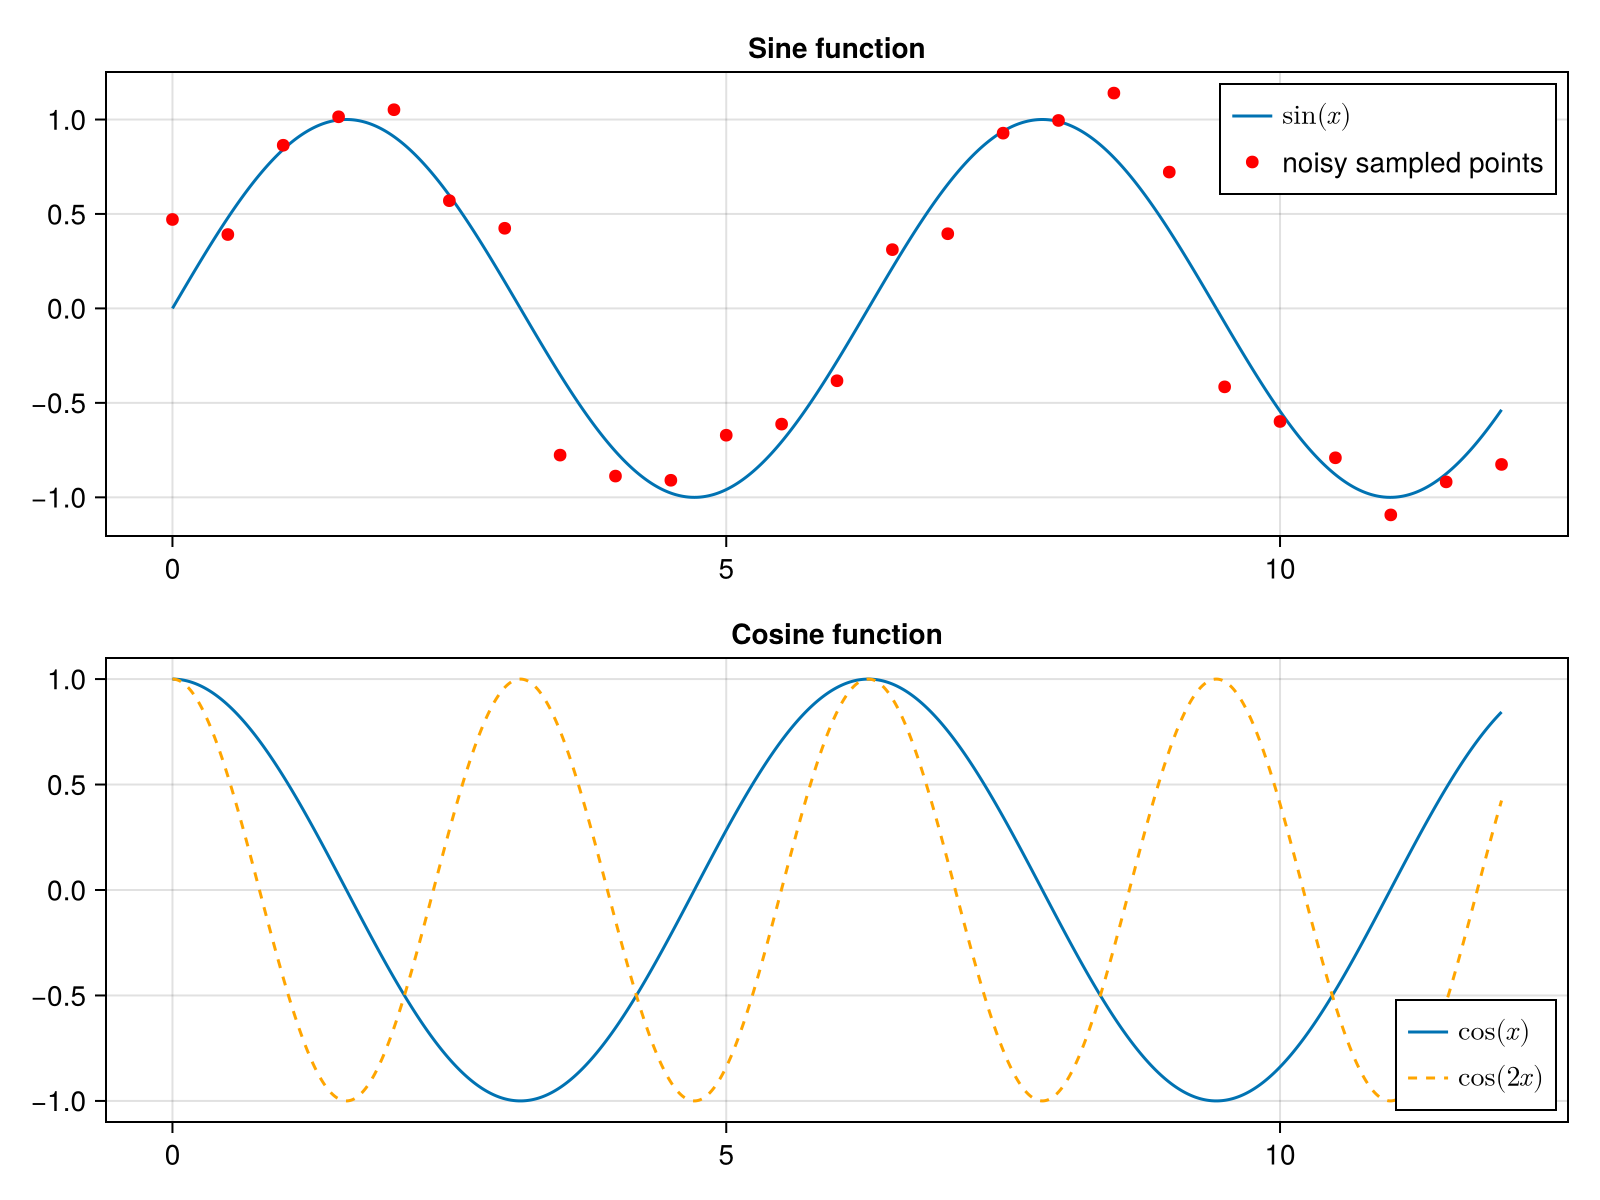

In [20]:
x0 = 0:0.01:12          # totally 1201 points
x_sample = x0[1:50:end] # sample every 50th point

fig = Figure(size = (800, 600))

# fig[1, 1]: Axis for the first row, first column
ax1 = Axis(fig[1, 1], title = "Sine function")
lines!(ax1, x0, sin.(x0), label = L"\sin(x)")
scatter!(
    ax1,
    x_sample,
    x -> sin(x) + 0.2 * randn(),
    label = "noisy sampled points",
    marker = :circle,
    color = :red
)
axislegend(ax1, position=:rt)

# fig[2, 1]: Axis for the second row, first column
ax2 = Axis(fig[2, 1], title = "Cosine function")
lines!(ax2, x0, cos.(x0), label = L"\cos(x)")
lines!(ax2, x0, cos.(2 * x0), label = L"\cos(2x)", linestyle = :dash, color = :orange)
axislegend(ax2, position=:rb)

fig